<a href="https://colab.research.google.com/github/bellington90/intro-to-machine-learning/blob/main/Brittny_Ellington_Assignment_1_Boston_Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: Comparing Two Linear Regression Models

**Student:** Brittny Ellington  
**Course:** Intro to Machine Learning Models  
**Dataset:** Boston Housing

## Objective

The goal of this assignment is to build and compare two linear regression models that predict `MEDV`, the median value of owner-occupied homes.

- **Model 1** uses all 13 available predictor features.
- **Model 2** uses a smaller group of six features selected because they have the strongest relationships with the target.

The two models are compared using **R-squared (R²)**, which measures how much of the variation in home values is explained by the model.

## Important dataset note

The Boston Housing dataset is a historical teaching dataset. The built-in `load_boston()` function was removed from newer versions of scikit-learn because of ethical concerns involving one of the variables. For this classroom exercise, the data is loaded directly from a CSV file instead.

## 1. Import the libraries

This cell imports the Python tools used to load and organize the data, build the regression models, and create a simple comparison chart.

In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

## 2. Load the Boston Housing data

This cell first looks for a local copy of `BostonHousing.csv`. If the file is not available locally, it loads a CSV copy from the internet.

In [ ]:
local_candidates = [
    Path("BostonHousing.csv"),
    Path("/content/BostonHousing.csv"),
    Path("/mnt/data/BostonHousing.csv"),
]

data_source = None

for candidate in local_candidates:
    if candidate.exists():
        data_source = candidate
        break

if data_source is None:
    data_source = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(data_source)

# Standardize the column names so they are easier to reference.
df.columns = [column.strip().upper() for column in df.columns]

print(f"Data source: {data_source}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head()

Data source: BostonHousing.csv
Rows: 506
Columns: 14


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## 3. Inspect the dataset

This cell checks the column names, data types, and missing values before modeling. Each row represents one observation, the predictor columns are the model's clues, and `MEDV` is the answer the model is trying to predict.

In [ ]:
print("Column names:")
print(df.columns.tolist())

print("\nMissing values by column:")
print(df.isna().sum())

print("\nSummary statistics:")
df.describe().T

Column names:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

Missing values by column:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


## 4. Separate the predictors from the target

- `X` represents the predictor features used as clues.
- `y` represents the target, `MEDV`, which is the median home value the models will predict.

In [ ]:
target = "MEDV"

if target not in df.columns:
    raise KeyError("The target column MEDV was not found in the dataset.")

X_all = df.drop(columns=[target])
y = df[target]

print(f"Number of predictor features: {X_all.shape[1]}")
print(f"Target column: {target}")

Number of predictor features: 13
Target column: MEDV


## 5. Model 1: Linear regression using all 13 features

This model uses every available predictor feature. A constant is added so the regression equation can estimate an intercept. The `fit()` command trains the model by finding the line, or higher-dimensional equivalent of a line, that best fits the data.

In [ ]:
X_model_1 = sm.add_constant(X_all, has_constant="add")
model_1 = sm.OLS(y, X_model_1).fit()

print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     108.1
Date:                Thu, 06 Aug 2026   Prob (F-statistic):          6.72e-135
Time:                        12:56:58   Log-Likelihood:                -1498.8
No. Observations:                 506   AIC:                             3026.
Df Residuals:                     492   BIC:                             3085.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.4595      5.103      7.144      0.0

## 6. Select six features for Model 2

To create a meaningfully different second model, this cell measures the absolute correlation between each predictor and `MEDV`. It then selects the six predictors with the strongest individual relationships to the target.

In [ ]:
correlations = (
    df.corr(numeric_only=True)[target]
    .drop(target)
    .abs()
    .sort_values(ascending=False)
)

selected_features = correlations.head(6).index.tolist()

print("Features selected for Model 2:")
print(selected_features)

print("\nAbsolute correlations with MEDV:")
print(correlations.head(6))

Features selected for Model 2:
['LSTAT', 'RM', 'PTRATIO', 'INDUS', 'TAX', 'NOX']

Absolute correlations with MEDV:
LSTAT      0.737663
RM         0.695360
PTRATIO    0.507787
INDUS      0.483725
TAX        0.468536
NOX        0.427321
Name: MEDV, dtype: float64


## 7. Model 2: Linear regression using six selected features

This model repeats the same regression process but uses only the six selected predictors. Comparing it with Model 1 shows what happens when the model is made simpler by removing features.

In [ ]:
X_model_2 = sm.add_constant(df[selected_features], has_constant="add")
model_2 = sm.OLS(y, X_model_2).fit()

print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     177.6
Date:                Thu, 06 Aug 2026   Prob (F-statistic):          2.26e-120
Time:                        12:56:58   Log-Likelihood:                -1551.2
No. Observations:                 506   AIC:                             3116.
Df Residuals:                     499   BIC:                             3146.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.1458      4.309      4.443      0.0

## 8. Compare the two models

R² shows the proportion of variation in `MEDV` explained by the model. Adjusted R² is similar, but it also accounts for how many features were used.

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Model 1: All 13 features",
        "Model 2: Six selected features",
    ],
    "Number of Features": [
        X_all.shape[1],
        len(selected_features),
    ],
    "R-squared": [
        model_1.rsquared,
        model_2.rsquared,
    ],
    "Adjusted R-squared": [
        model_1.rsquared_adj,
        model_2.rsquared_adj,
    ],
})

comparison

,Model,Number of Features,R-squared,Adjusted R-squared
0,Model 1: All 13 features,13,0.740643,0.733790
1,Model 2: Six selected features,6,0.681022,0.677186


## 9. Visual comparison

This chart provides a quick visual comparison of the R² scores. A taller bar means the model explained more of the variation in median home values.

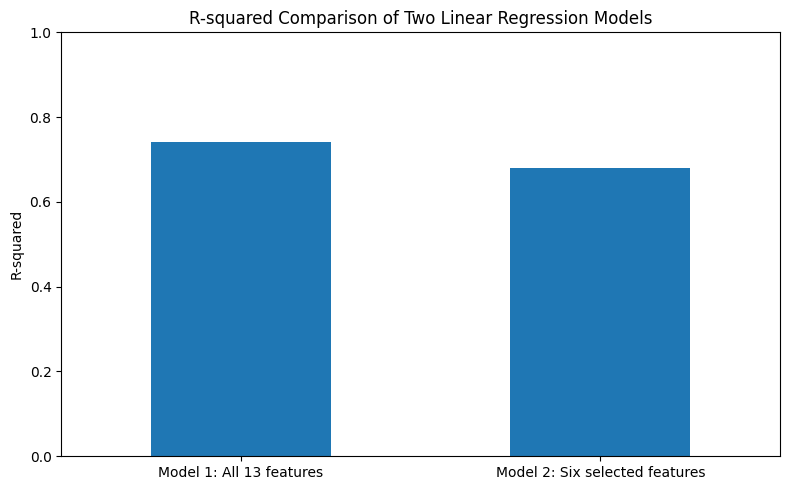

In [ ]:
ax = comparison.plot(
    x="Model",
    y="R-squared",
    kind="bar",
    legend=False,
    figsize=(8, 5),
)

ax.set_title("R-squared Comparison of Two Linear Regression Models")
ax.set_xlabel("")
ax.set_ylabel("R-squared")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Conclusion

Model 1 used all 13 predictor features and produced an R² of approximately **0.741**, meaning that it explained about **74.1%** of the variation in median home values. Model 2 used the six features with the strongest individual relationships to `MEDV` and produced an R² of approximately **0.681**, explaining about **68.1%** of the variation.

Model 1 performed better based on R² because the additional features contributed information that helped explain more of the differences in home values. Model 2 was simpler and easier to interpret, but removing seven predictors reduced its overall explanatory power. This comparison shows that a simpler model can still explain much of the outcome, although it may sacrifice some model fit.

## Plain-language takeaway

The first model had more clues available, so it explained more of what caused home values to differ. The second model used fewer clues and was easier to understand, but it lost some useful information.